# Laboratorio 1 - Exploración, preparación y regresión lineal

## AlpesPlanck

**Integrantes:**
- Daniel Esteban Pardo Pardo
- Samuel Andrés Molina Luna

**Curso:** ISIS2611 - Aprendizaje de Máquina
**Fecha:** 31 de Agosto 2026

# 1. Contexto
El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. A partir de un histórico de datos que se nos ha proporcionado, realizaremos una exploración de los mismos para entender su composición y validar los principios de calidad (unicidad, completitud, validez y consistencia) estudiados en el curso. <br><br>
De esta manera podremos llevar a cabo un proceso de ingeniería de datos que nos permitirá preparar los datos proporcionados para, finalmente, elaborar dos modelos de **regresión lineal** con el uso de **pipelines**. Estos modelos serán comparados a partir de métricas estadísticas precisas para elegir el parezca tener mejor desempeño y aplicarlo sobre un conjunto de datos sin etiquetas.      

# 2. Carga de datos

### Librerías a usar en el transcurso del laboratorio
Librerías de Python para el procesamiento y analisis de datos como:<br>

- Pandas
- Scikit-Learn
- Matplotlib, Seaborn


In [33]:
# Importación de las librerías a usar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Cargar datos a DataFrames

##### DataSet de entrenamiento

In [21]:
data = pd.read_csv('data/Datos Lab 1.csv')
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


#### DataSet de prueba (Sin etiquetas)

In [22]:
data_test = pd.read_csv('data/Datos Test Lab 1.csv')
data_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,0.18,3.13,0.5552,1.7068,0.40,5.17,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,0.21,4.01,1.0960,2.8128,0.52,5.37,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,0.60,4.46,0.8034,3.9316,1.28,6.49,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,0.25,4.06,0.8433,3.4434,0.48,6.25,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,0.45,3.21,0.6245,2.4610,0.80,4.41,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


Notamos que el DataFrame que corresponde a los datos de entrenamiento tiene una columna más que el de los datos de prueba. Esta columna adicional corresponde a `temp_max_manana`; nuestra variable objetivo y la que completaremos en el conjunto de datos de prueba una vez tengamos nuestro modelo de regresión lineal definido.

##### Diccionario de datos
Nos remitiremos a este diccionario para entender a qué hacer referencia cada unos de las columnas de nuestra DataFrames y estudiar, en las secciones posteriores, la calidad de los datos.

In [23]:
data_dict = pd.read_excel('data/Diccionario de datos.xlsx')
print(data_dict.to_markdown(index=False))

| variable          | tipo     | descripcion                                                                                              |
|:------------------|:---------|:---------------------------------------------------------------------------------------------------------|
| fecha             | texto    | Fecha de la observación, en formato día.mes.año.                                                         |
| presion_media     | numérico | Presión atmosférica media del día (mbar).                                                                |
| presion_min       | numérico | Presión atmosférica mínima del día (mbar).                                                               |
| presion_max       | numérico | Presión atmosférica máxima del día (mbar).                                                               |
| presion_desv      | numérico | Desviación típica de la presión durante el día (mbar).                                                   |
| humedad_media     

# 3. Exploración de datos

### 3.1 Dimensiones y tipos de datos

El conjunto de datos de entrenamiento tiene en total 2.576 registros y 27 columnas. Vemos que la
mayoria de las variables son numericas continuas (float64) como se puede observar en las mediciones de presion, humedad, viento 
y rafagas; mientras que fecha, estacion_anio, mes y sector_viento son 
variables de tipo object (texto).

In [24]:
print(f"Dimensiones: {data.shape[0]} filas, {data.shape[1]} columnas")

Dimensiones: 2576 filas, 27 columnas


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

### 3.2 Valores nulos

Ahora se revisa la cantidad de valores nulos por columna para poder sacar el porcentaje de datos faltantes y decidir como tratarlos en la etapa de preparacion.

In [26]:
nulos = data.isnull().sum()
porcentaje_nulos = (nulos / len(data) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'porcentaje': porcentaje_nulos}).sort_values('nulos', ascending=False)

,nulos,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
estacion_anio,88,3.42
mes,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
humedad_min,80,3.11
viento_norte,80,3.11


Vemos que todas las columnas presentan valores nulos en los porcentajes entre 2.37 a 3.69 (casi 4%), tambien se tiene la variable `temp_max_manana`, nuestra variable objetivo, que tiene el mayor numero de valores nulos con un total de 95 (3.69%).

### 3.3 Estadísticas descriptivas
En esta sección encontraremos un compilado de las medidas estadísticas más relevantes de los datos. Inicialmente veremos aquellos de tipo numérico identificados anteriormente.

In [27]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(data.describe())

       presion_media  presion_min  presion_max  presion_desv  humedad_media  humedad_min  humedad_max  humedad_desv  viento_media   viento_min   viento_max  viento_desv  rafaga_media   rafaga_min   rafaga_max  rafaga_desv  viento_norte  viento_este  direccion_viento  registros_del_dia         anio  dia_del_anio  temp_max_manana
count    2501.000000  2502.000000  2512.000000   2496.000000    2502.000000  2496.000000  2490.000000   2515.000000   2490.000000  2485.000000  2495.000000  2504.000000   2498.000000  2504.000000  2503.000000  2497.000000   2496.000000  2512.000000       2497.000000        2499.000000  2490.000000   2508.000000      2481.000000
mean     1010.494271   986.684409   991.704244      1.752041      52.413586    45.094067    90.236582     10.606821      3.814103     1.417799     7.647484    13.859643      2.988370    -2.639322     6.946058    -5.763253     -1.128463    -0.410159        172.104573         144.090836  2011.995582    182.690989        13.863309
std       

#### Inconsistencias detectadas en el dataset meteorológico

A partir de la operación data.describe(), se encontraron ciertas inconsistencias en los datos numéricos de DataFrame. Agrupamos los hallazgos en dos categorías: valores físicamente imposibles e inconsistencias lógicas entre columnas relacionadas.

#### Valores físicamente imposibles o muy improbables

| Columna | Valor problemático | Motivo |
|---|---|---|
| `presion_min` | min = 913.6 | Una presión atmosférica de ~913 mbar es muy improbable en la Tierra (rango normal ~980–1040 mbar). |
| `presion_media` | max = 9939.918 | Una presión atmosférica de ~9940 mbar no existe en la Tierra (rango normal ~980–1040 mbar). |
| `humedad_min` | max = 103.31 | La humedad relativa no puede superar el 100%. |
| `humedad_media` | min = 0.0047 | Humedad relativa prácticamente 0% es extremadamente rara. |
| `humedad_min` | min = 0.2377 | Mismo problema que el anterior. |
| `rafaga_media` | min = -1386.27 | La velocidad de ráfaga no puede ser negativa. |
| `rafaga_min` | min = -9999 | Valor imposible, probablemente patrón clásico de "valor centinela" para datos faltantes. |
| `rafaga_desv` | mean = -5.76, min = -232.26 | Una desviación estándar nunca puede ser negativa. |
| `viento_desv` | max = 3319.03, std = 76 | Incompatible matemáticamente con un viento máximo observado de solo ~45. |
| `viento_norte` | min = -1250.46 | Componente de viento con magnitud absurda frente a un máximo de apenas 4.81. |
| `registros_del_dia` | max = 287 | Valor imposible, el máximo factible en un día es de 144 registros. |
| `temp_max_manana` | max = 63.05°C | El récord mundial verificado es ~56.7°C (Death Valley). 63°C es prácticamente imposible. |

#### Inconsistencias lógicas entre columnas relacionadas

- **`presion_media` (mean = 1010.49) > `presion_max` (mean = 991.70)**: el promedio no puede superar al máximo diario. Confirma contaminación por los valores tipo "9939".
- **`viento_min` (max = 45.18) > `viento_media` (max = 24.75)**: el mínimo de viento de un día no debería superar el máximo observado en toda la variable de viento medio; sugiere valores mal asignados o intercambiados entre columnas.

Ahora haremos la misma operación para los datos tipo object; esto nos dará una aproximación a problemáticas que estudiaremos a fondo más adelante como la completitud y consistencia de estos datos.

In [28]:
print(data.describe(include=object))

             fecha estacion_anio   mes sector_viento
count         2504          2488  2488          2505
unique        2486            28    61            33
top     2009-03-05     primavera   May            SO
freq             2           517   127           695


A partir de la operación describe ejecutada se pueden observar los siguientes problemas:
- Existen registros que tienen el mismo valor para la columna `fecha`, que la frecuencia del dato con mayor moda sea 2 nos indica que no hay más de dos registros que compartan una fecha.
- Hay 28 valores únicos en la columna `estacion_anio`, pese a solo existir 4 estaciones, probablemente identifiquemos un problema de consistencia.
- Lo mismo se identifica para los valores únicos de `mes` (diferente a 12) y `sector_viento` (diferente a 8).

### 3.4 Duplicados

Aqui se revisa si existen filas completamente duplicadas así como fechas repetidas ya que cada fila deberia representar la observacion de un unico día.

In [29]:
print("Filas duplicadas:", data.duplicated().sum())
print("Fechas duplicadas:", data['fecha'].duplicated().sum())
data[data['fecha'].duplicated(keep=False)].sort_values('fecha').head(10)

Filas duplicadas: 4
Fechas duplicadas: 89


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48,983.54,3.9853,86.731100,69.110,97.6,9.7926,10.09692,1.440,26.532000,178.4300,4.2533,0.88,10.13,-122.6500,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48,983.54,3.9853,86.731100,69.110,97.6,9.7926,10.09692,1.440,26.532000,178.4300,4.2533,0.88,10.13,-122.6500,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67,962.54,0.8964,94.294400,86.000,97.8,2.8296,1.29080,0.040,3.450000,0.7870,2.2142,0.25,5.25,1.0716,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67,962.54,0.8964,NaN,86.000,97.8,2.8296,1.29080,0.040,3.450000,0.7870,2.2142,0.25,5.25,1.0716,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99,999.41,0.9205,77.500000,51.090,99.6,18.9020,1.84440,0.030,5.290000,1.6412,3.0808,0.25,9.00,2.4761,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99,999.41,0.9205,77.500000,51.090,99.6,18.9020,1.84440,0.030,5.290000,1.6412,3.0808,0.25,9.00,2.4761,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45,991.40,3.7836,1.021309,0.801,96.8,5.9641,4.53492,0.648,16.236000,87.1400,2.3154,0.40,9.21,-82.1800,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
341,2009-12-08,983.849000,979.45,991.40,3.7836,0.877951,0.801,96.8,5.9641,4.53492,0.648,16.236000,87.1400,2.3154,0.40,9.21,-82.1800,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2566,2010-08-14,991.272748,989.22,991.29,0.4346,84.386400,65.120,95.7,9.4681,1.70860,0.320,2.628399,0.8538,2.8174,0.62,5.92,1.1893,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
590,2010-08-14,990.482800,989.22,991.29,0.4346,84.386400,65.120,95.7,9.4681,1.70860,0.320,2.628399,0.8538,2.8174,0.62,5.92,1.1893,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000


Se identifican 4 filas y 89 fechas duplicadas, tambien se observa que la mayoria de estas fechas corresponden a registros con valores distintos en las demas columnas, osea no son copias exactas como tal sino errores de asignacion de fecha entre observaciones de dias distintos. Adicionalmente a esto, una de las 4 filas duplicadas contiene el valor de presion_media con 9784.115000 identificado previamente lo que implica que ese error esta presente en ambas copias.

Por ultimo se detecta que las columnas mes y estacion_anio son inconsistentes con dia_del_anio, por ejemplo se presenta el dia 22 del año que corresponde a enero e invierno, pero en data frame aparece etiquetado como octubre/verano, lo que indica que estas columnas no son confiables y deberan recalcularse a partir de fecha o dia_del_anio en la etapa de preparacion.

### 3.5 Distribuciones de las variables
Elaboraremos gráficos que nos ayuden a entender la distribución de las variables numéricas del conjunto de datos. El objetivo es poder poner en evidencia cuáles son los potenciales sesgos de cada variable

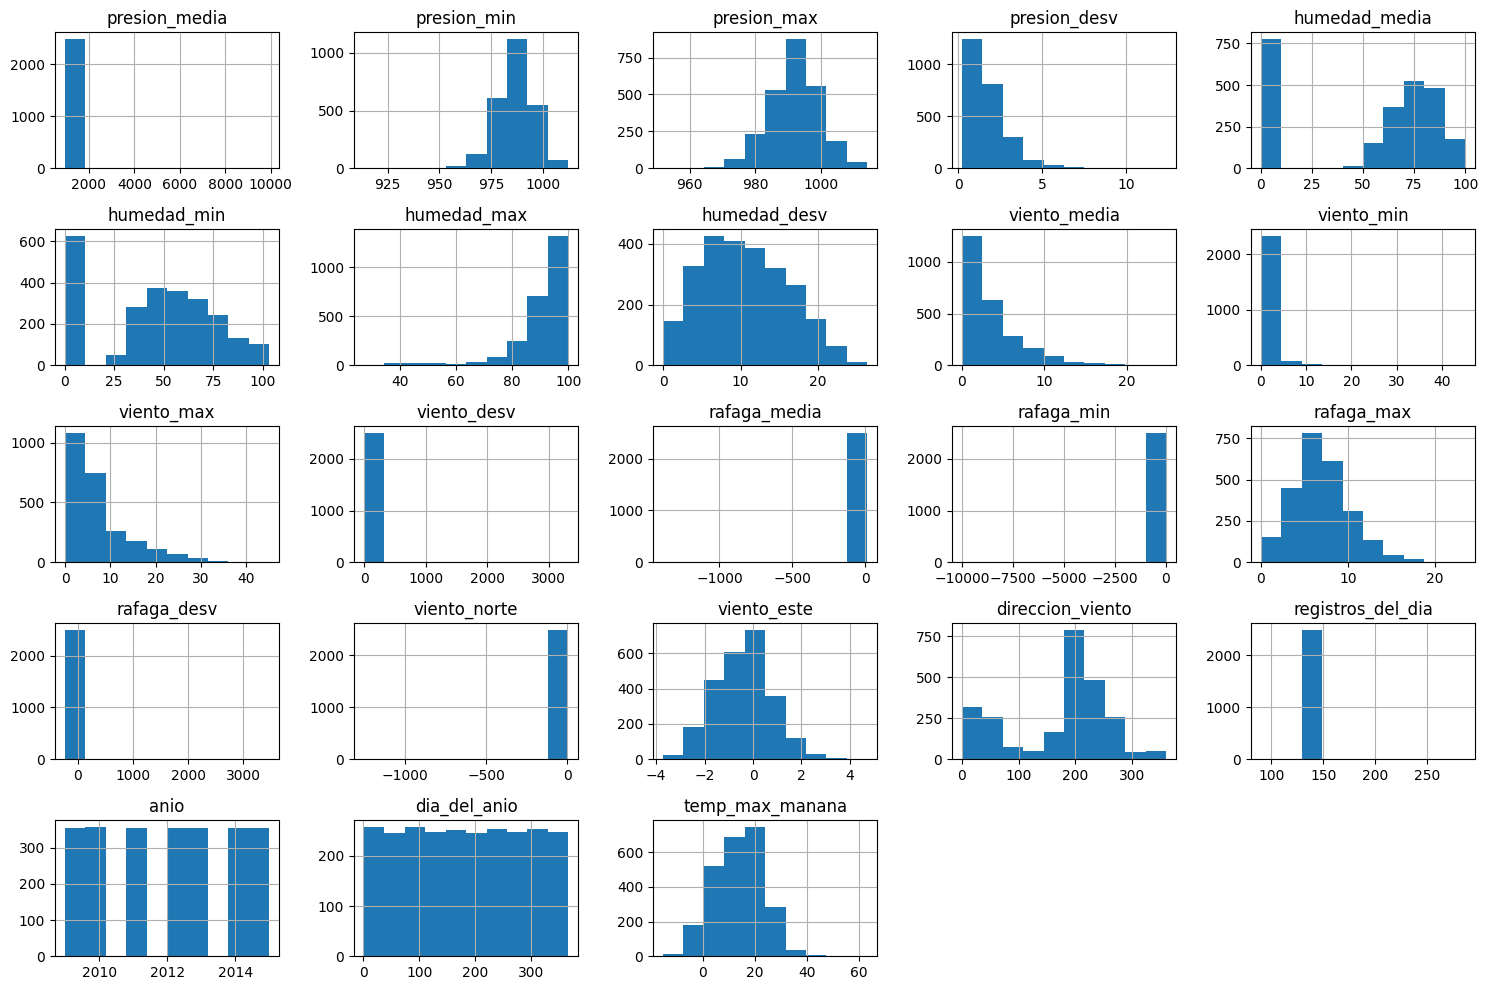

In [30]:
data.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Análisis de las distribuciones: Los histogramas muestran que las variables meteorológicas presentan comportamientos distintos. Algunas variables, como `viento_media`, `viento_max` y `rafaga_max`, presentan distribuciones asimétricas con colas hacia valores altos, mientras que otras se encuentran más concentradas en rangos específicos.<br><br>
También se identifican posibles valores extremos en variables como `presion_desv`, `rafaga_desv` y `viento_norte`, que deberán ser analizados antes de determinar si corresponden a observaciones válidas o anomalía. <br><br>
Por su lado, variables como `presion_min`, `presion_max` y `temp_max_manana` (nuestra variable objetivo) muestran distribuciones aproximadamente normales centradas en rangos físicamente coherentes.

En un análisis más profundo de nuestra variable objetivo `temp_max_manana`, realizaremos un boxplot que nos permitirá visualizar los outliers registrados, los cuales contabilizaremos y reportaremos su porcentaje relativo. Esto con la intención de entender la distribución de la variable y cómo esta impacta el modelo de regresión lineal que vamos a desarrollar.

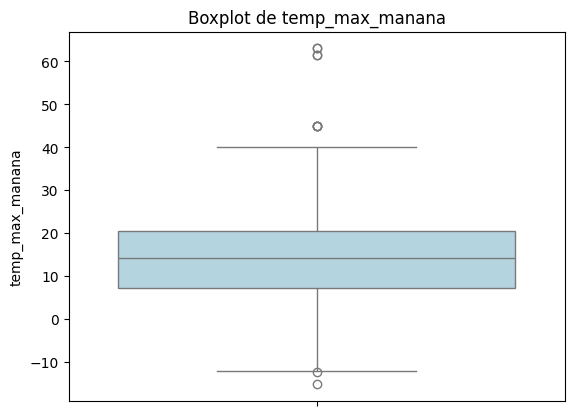

IQR: 13.15
Límite inferior: -12.42
Límite superior: 40.19
Cantidad de outliers: 10
Porcentaje relativo de outliers: 0.40%


In [32]:
sns.boxplot(data=data, y=data['temp_max_manana'], color='lightblue')
plt.title('Boxplot de temp_max_manana')
plt.show()

Q1 = data['temp_max_manana'].quantile(0.25)
Q3 = data['temp_max_manana'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = data[(data['temp_max_manana'] < limite_inferior) | (data['temp_max_manana'] > limite_superior)]
num_outliers = len(outliers)
total_validos = data['temp_max_manana'].count()
porcentaje_outliers = (num_outliers / total_validos) * 100

print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Cantidad de outliers: {num_outliers}")
print(f"Porcentaje relativo de outliers: {porcentaje_outliers:.2f}%")

El análisis mediante el método del Rango Intercuartílico (IQR) identificó únicamente 10 valores atípicos en la variable objetivo, lo que representa aproximadamente un 0.4% del total de datos válidos.Este resultado es altamente positivo para la fase de modelado predictivo por las siguientes razones:
- Alta estabilidad y calidad de la variable: La baja presencia de outliers confirma que la distribución de la temperatura máxima de la mañana es continua, coherente y prácticamente libre de errores.
- Menor sesgo en métricas de evaluación: Las métricas de error cuadrático habituales en regresión (como RMSE o R^2) son altamente sensibles a valores extremos. Al contar con un porcentaje tan marginal de datos atípicos, el modelo no sufrirá penalizaciones artificiales ni sesgos severos durante la fase de entrenamiento y validación.
- Preservación de la muestra: Al ser tan solo 10 registros, es posible aislarlos, imputarlos o eliminar de manera segura estos días atípicos sin perder representatividad ni volumen de datos en el conjunto de entrenamiento.

### 3.6 Correlaciones entre las variables
A través de un mapa de calor analizaremos la correlación que existe entre las distintas variables numéricas del conjunto de datos. Esto nos ayudará a identificar tanto las variables que más correlación tienen con la variable objetivo así como a detectar posibles problemas de colinealidad entre las variables explicativas candidatas.

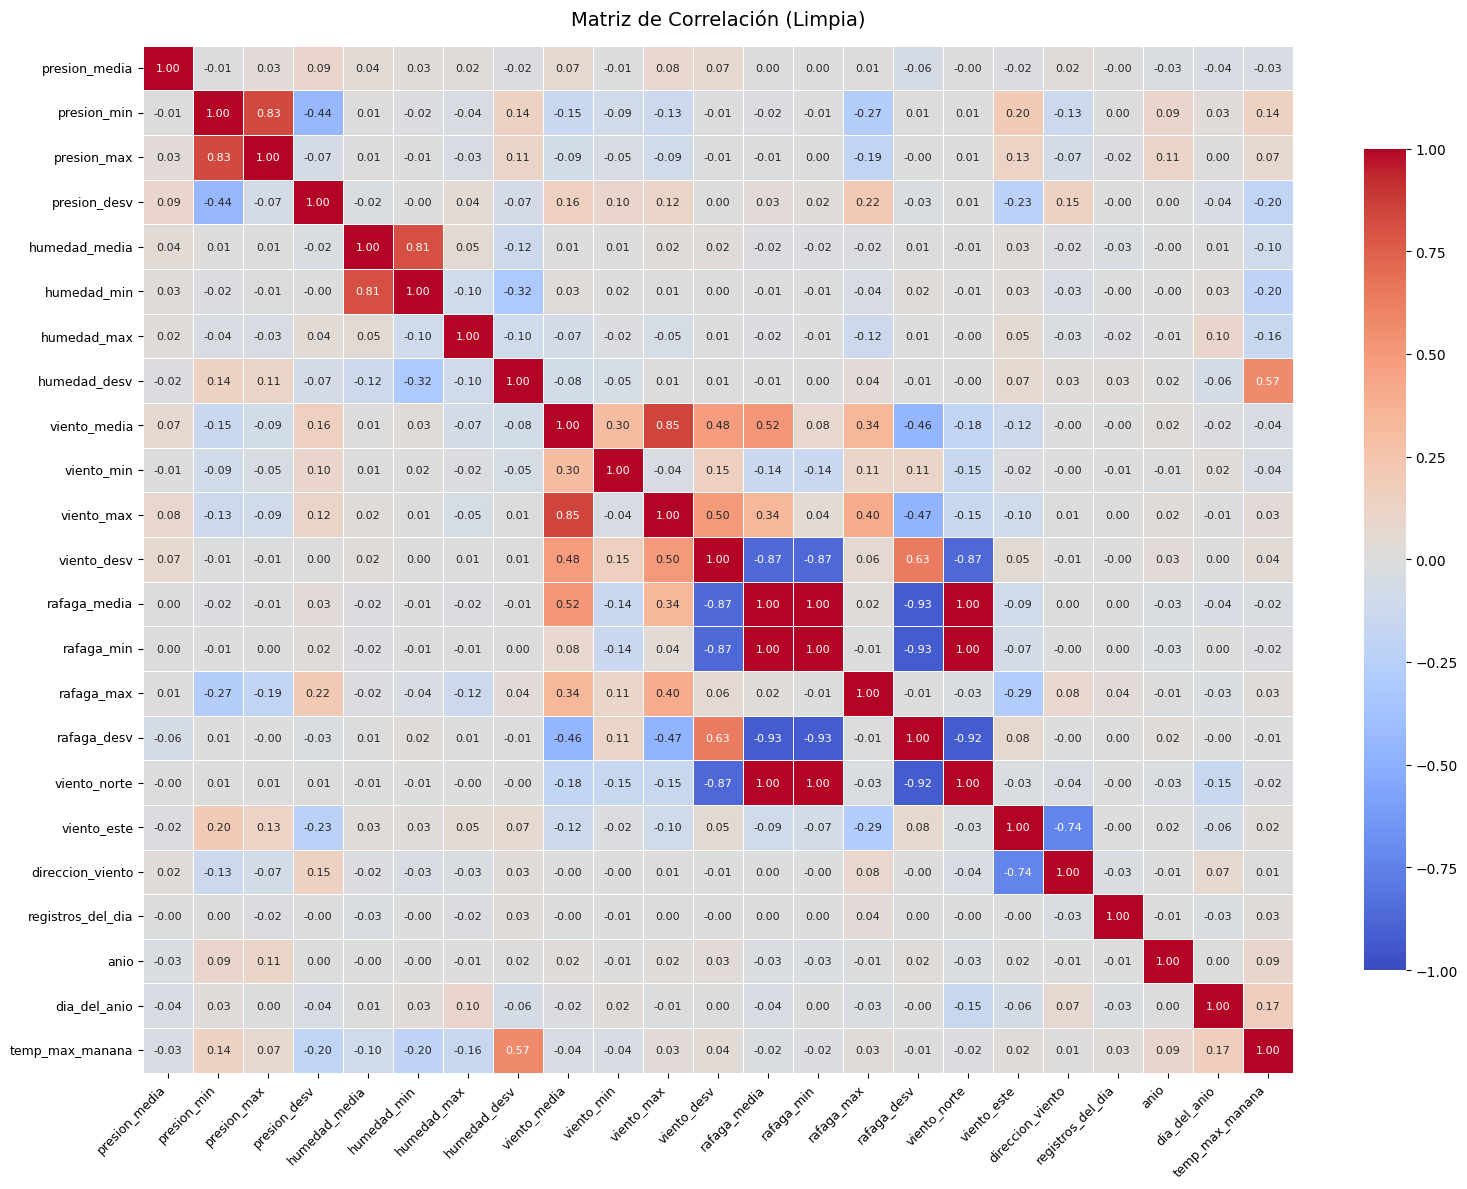

In [ ]:
data_numbers = data.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
sns.heatmap(
    data_numbers.corr(), 
    annot=True, 
    fmt=".2f",                 
    cmap="coolwarm",            
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    annot_kws={"size": 8},    
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlación (Limpia)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

Con el mapa de calor nos podemos dar cuenta que la variable que más se correlaciona con la objetivo es `humedad_desv`, es decir, la desviación en la métrica de la humedad es lo que más se correlaciona con la temperatura máxima registrada al día siguiente. El resto de variables numéricas tienen una correlación con la variable objetivo que tiende a 0. <br><br>
Adicionalmente, este mapa pone en evidencia algo intuitivo: las variables que responden a métricas metereológicas están muy correlacionadas entre sí, por ejemplo, entre `viento_desv` y `viento_max`. Es decir, la colinealidad entre este tipo de variables es un factor a considerar en el diseño del modelo.

### 3.7 Análisis de los 4 principios de calidad de los datos
Dada la exploración previa de los datos, esta sección se propone sintetizar los datos recabados en los 4 principios de calidad de los datos, explicando hasta qué punto el DataFrame entregado por AlpesPLanck los respeta.

#### 3.7.1 Unicidad 
Se detectaron 4 filas completamente duplicadas e inconsistencias en la variable temporal con 89 fechas repetidas, lo que requiere una depuración de registros para no alterar las métricas de entrenamiento.

#### 3.7.2 Completitud
El dataset presenta una pérdida moderada de información (entre el 2.37% y 3.69% de valores nulos por columna). La variable objetivo (temp_max_manana) registra 95 valores faltantes (3.69%), los cuales pueden imputarse mediante técnicas para series temporales o filtrarse sin comprometer significativamente el volumen de datos.

#### 3.7.3 Consistencia
Existen severas contradicciones de formato y categorización. Se observan mezclas de idiomas y formatos en las variables de mes y estacion_anio (ej. January, Enero, JULY, East), además de picos anómalos de registros agrupados en $0\%$ para la humedad.

In [ ]:
cols_object = data.select_dtypes(include=['object']).columns

print("=== CONTEO DE INCONSISTENCIAS EN VARIABLES CATEGÓRICAS ===\n")

for col in cols_object:
    print(f"--- Variable: {col} ---")
    conteo = data[col].value_counts(dropna=False)
    print(conteo)
    print(f"Total de categorías distintas: {data[col].nunique(dropna=False)}")
    print("-" * 40)

=== CONTEO DE INCONSISTENCIAS EN VARIABLES CATEGÓRICAS ===

--- Variable: fecha ---
fecha
NaN           72
2009-05-02     2
2009-03-05     2
2010-10-25     2
2010-08-14     2
              ..
2009-01-19     1
2009-01-20     1
2009-01-21     1
2015-12-04     1
2009-01-04     1
Name: count, Length: 2487, dtype: int64
Total de categorías distintas: 2487
----------------------------------------
--- Variable: estacion_anio ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
berano                   17
primaveraa               17
fall                     15
winter                   15
verno                    14
Otoño                    12
invernio                 11
otoño                    11
PRIMAVERA                10


#### 3.7.4 Validez
Se identificaron valores fuera de rango físico real y códigos de error no procesados. Destacan valores centinela (como -9999 en rafaga_min), presiones imposibles (> 9000 mbar) y humedades superiores al 100%. Estos datos anómales distorsionan los histogramas y comprometen la integridad del modelo que se busca realizar.

**Conclusión:** Aunque la variable objetivo (`temp_max_manana`) muestra un comportamiento muy estable con solo 10 outliers reales (0.4%), el conjunto de datos general requiere una fase rigurosa de limpieza (remoción de duplicados, reemplazo de valores centinelas y estandarización y normalización de las variables numéricas) antes de avanzar hacia la selección de características y el modelado predictivo a través de la regresión lineal.